# Final Project Notebook

Getting started: simulate a quadruple star system in REBOUND

In [35]:
%matplotlib widget
import matplotlib.pyplot as plt
import rebound
import time
import numpy as np
plt.close()

# set up the parameters
m_Aa = 1.75 # solar masses
m_Ab = 1.36 # solar masses
m_B = 1.48 # solar masses
m_C = 1.0 # solar masses

a_Aa_Ab = 13.576 # solar radii
a_A_B = 96.62 # solar radii
a_AB_C = 769.9 # solar radii

e_Aa_Ab = 0.00735
e_A_B = 0.22367
e_AB_C = 0.274

omega_Aa_Ab = 199.4 # deg
omega_A_B = 190.05 # deg
omega_AB_C = 289.0 # deg

inc_Aa_Ab = 88.7 # deg
inc_A_B = 89.05 # deg
inc_AB_C = 90.3 # deg

# 1. Simulate the quadruple system and plot the evolution of semi-major axis & eccentricity

## start easy: integrate over 1 period of the outer most star

-99.81465620922191 -15.662141479718262 0.0
-101.0410917142938 -29.08243448738125 0.0
-99.12421702917943 53.46814956191014 0.0
458.79537430076346 -12.172002859281541 0.0
<rebound.Orbit instance, a=13.576 e=0.007349999999999934 inc=0.0 Omega=0.0 omega=4.621255477432757 f=6.750155989720952e-14> 178.22040153493995
<rebound.Orbit instance, a=96.62000000000005 e=0.22367000000000015 inc=0.0 Omega=0.0 omega=1.5544407846124155 f=1.7763568394002505e-15> 2785.3134434898793
<rebound.Orbit instance, a=769.9000000000003 e=0.27400000000000024 inc=0.0 Omega=0.0 omega=6.256661176918616 f=6.283185307179582> 56770.8561597692


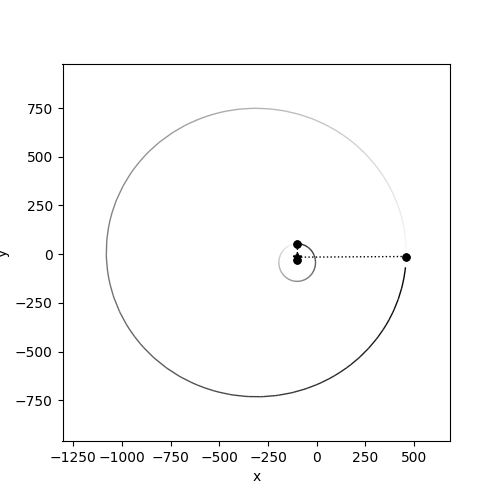

In [311]:
sim = rebound.Simulation()
sim.add(m=m_Aa, hash='star_Aa')
sim.add(m=m_Ab, a=a_Aa_Ab, e=e_Aa_Ab, omega=omega_Aa_Ab, hash='star_Ab')

sim.add(m=m_B, a=a_A_B, e=e_A_B, omega=omega_A_B, hash='star_B')
sim.add(m=m_C, a=a_AB_C, e=e_AB_C, omega=omega_AB_C, hash='star_C')


sim.move_to_com()

# plot the positions and instantaneous orbit
op = rebound.OrbitPlot(sim, periastron=True)

# output info about the particles and the orbit
for p in sim.particles:
    print(p.x, p.y, p.z)
for o in sim.orbits(): 
    print(o, o.P)

In [312]:
p_orb = sim.particles['star_C'].P

Norbits = 1
Noutputs = 2000

times = np.zeros(Noutputs)

xvec1 = [sim.particles['star_Aa'].x]
yvec1 = [sim.particles['star_Aa'].y]
vxvec1 = [sim.particles['star_Aa'].vx]
vyvec1 = [sim.particles['star_Aa'].vy]

xvec2 = [sim.particles['star_Ab'].x]
yvec2 = [sim.particles['star_Ab'].y]
a2 = np.zeros(Noutputs)
e2 = np.zeros(Noutputs)
vxvec2 = [sim.particles['star_Ab'].vx]
vyvec2 = [sim.particles['star_Ab'].vy]

xvec3 = [sim.particles['star_B'].x]
yvec3 = [sim.particles['star_B'].y]
vxvec3 = [sim.particles['star_B'].vx]
vyvec3 = [sim.particles['star_B'].vy]
a3 = np.zeros(Noutputs)
e3 = np.zeros(Noutputs)

xvec4 = [sim.particles['star_C'].x]
yvec4 = [sim.particles['star_C'].y]
vxvec4 = [sim.particles['star_C'].vx]
vyvec4 = [sim.particles['star_C'].vy]
a4 = np.zeros(Noutputs)
e4 = np.zeros(Noutputs)

op2, = plt.plot(xvec1, yvec1)

for i in range(Noutputs):

    op.sim.integrate(sim.t + (Norbits/Noutputs)*p_orb)

    times[i] = sim.t

    # store the trajectory + velocity of star Aa
    xvec1.append(sim.particles['star_Aa'].x)
    yvec1.append(sim.particles['star_Aa'].y)
    vxvec1.append(sim.particles['star_Aa'].vx)
    vyvec1.append(sim.particles['star_Aa'].vy)

    # store the trajectory + velocity + semi major axis + eccentricity of star Ab
    xvec2.append(sim.particles['star_Ab'].x)
    yvec2.append(sim.particles['star_Ab'].y)
    vxvec2.append(sim.particles['star_Ab'].vx)
    vyvec2.append(sim.particles['star_Ab'].vy)
    a2[i] = sim.particles['star_Ab'].a
    e2[i] = sim.particles['star_Ab'].e

    # store the trajectory + velocity + semi major axis + eccentricity of star B
    xvec3.append(sim.particles['star_B'].x)
    yvec3.append(sim.particles['star_B'].y)
    vxvec3.append(sim.particles['star_B'].vx)
    vyvec3.append(sim.particles['star_B'].vy)
    a3[i] = sim.particles['star_B'].a
    e3[i] = sim.particles['star_B'].e

    # store the trajectory + velocity + semi major axis + eccentricity of star C
    xvec4.append(sim.particles['star_C'].x)
    yvec4.append(sim.particles['star_C'].y)
    vxvec4.append(sim.particles['star_C'].vx)
    vyvec4.append(sim.particles['star_C'].vy)
    a4[i] = sim.particles['star_C'].a
    e4[i] = sim.particles['star_C'].e

    # update the plot to animate it
    op.update() #updateLimits=True) 
    op2.set_data((xvec1,yvec1)) 
    time.sleep(0.001)
    op.fig.canvas.draw()

## Sanity check: let's make sure our REBOUND quantities for the period are correct

In [109]:
def P_conversion_factor(a_unit, M_unit):
    '''
    Factor to multiply the REBOUND period by to retrieve SI units (seconds)

    P_SI = f*P_rebound

    a_unit: units of length used
        solar radius = 6.957e8 meters
        astronomical unit = 1.5e11 meters

    M_unit: units of mass used
        solar mass = 2e30 kg
        earth mass = 6e24 kg
    '''
    G = 6.67e-11
    f = np.sqrt((a_unit**3)/(G*M_unit))
    return f

In [110]:
P_conversion_factor(a_unit=6.957e8, M_unit=2e30)

np.float64(1588.748268501705)

In [113]:
# from the REBOUND sim cell above, we have the period of the inner binary in REBOUND units, which should be equal to 3.28 days 
# f * P_rebound (gives you seconds; convert to days)
1588.748268501705 * 178.22040153493995 / (24*3600)

3.2771684531286396

It works!:-) Let's make it one easy function

In [114]:
def check_P_in_days(a_unit, M_unit, P_rebound):
    
    f = P_conversion_factor(a_unit, M_unit)
    P_seconds = f*P_rebound
    P_days = P_seconds / (24*3600)

    return P_days

In [115]:
check_P_in_days(a_unit=6.957e8, M_unit=2e30, P_rebound=178.22040153493995)

np.float64(3.2771684531286396)

Now let's integrate:

First, let's look at the evolution of the semi-major axis and eccentricity of each stellar sub-system to see if any chaotic behavior arises

Text(0.5, 1.0, 'Inner binary (Aa-Ab)')

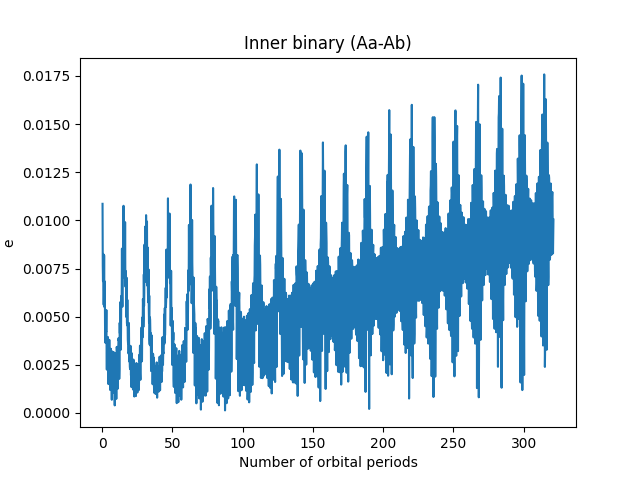

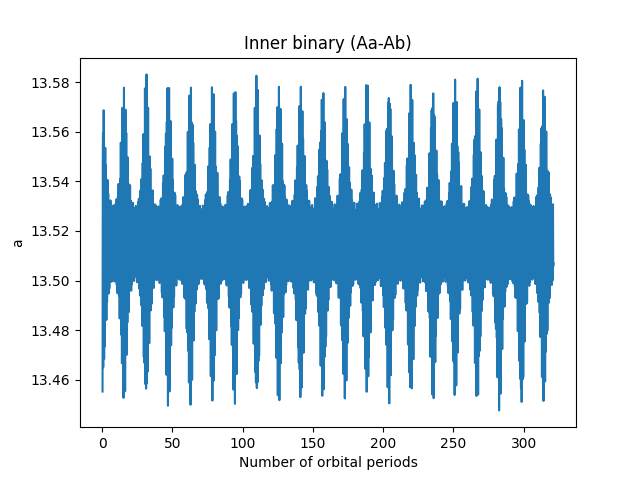

In [101]:
P_Aa_Ab = sim.particles['star_Ab'].P
P_A_B = sim.particles['star_B'].P
P_AB_C = sim.particles['star_C'].P

plt.close('all')

plt.figure(0)
plt.plot(times/P_Aa_Ab, e2)
#plt.xlim([0, 300])
#plt.ylim([0.2, 0.25])

plt.xlabel('Number of orbital periods')
plt.ylabel('e')
plt.title('Inner binary (Aa-Ab)')

plt.figure(1)
plt.plot(times/P_Aa_Ab, a2)
#plt.xlim([0, 300])
#plt.ylim([0.675, 0.7])

plt.xlabel('Number of orbital periods')
plt.ylabel('a')
plt.title('Inner binary (Aa-Ab)')


Text(0.5, 1.0, 'Third star (A-B)')

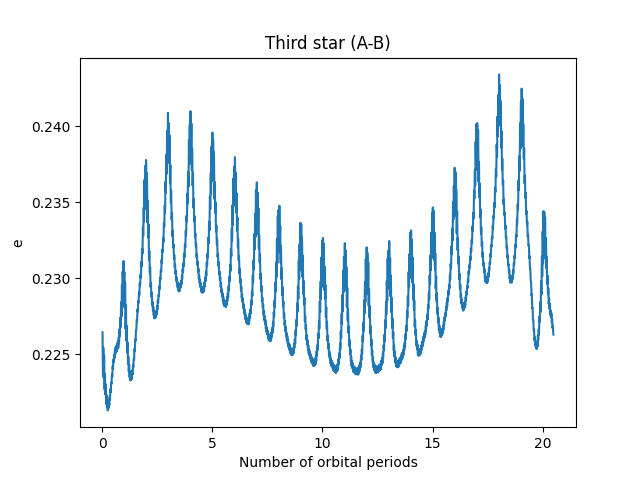

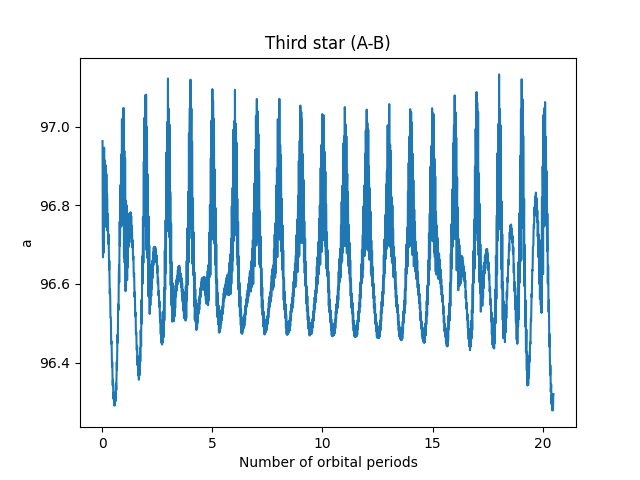

In [102]:
plt.close('all')

plt.figure(0)
plt.plot(times/P_A_B, e3)
#plt.xlim([0, 300])
#plt.ylim([0.2, 0.25])

plt.xlabel('Number of orbital periods')
plt.ylabel('e')
plt.title('Third star (A-B)')

plt.figure(1)
plt.plot(times/P_A_B, a3)
#plt.xlim([0, 300])
#plt.ylim([0.675, 0.7])

plt.xlabel('Number of orbital periods')
plt.ylabel('a')
plt.title('Third star (A-B)')

Text(0.5, 1.0, 'Fourth star (AB-C)')

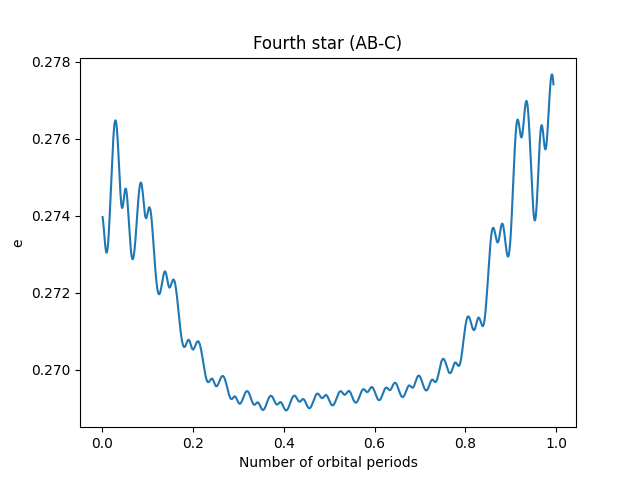

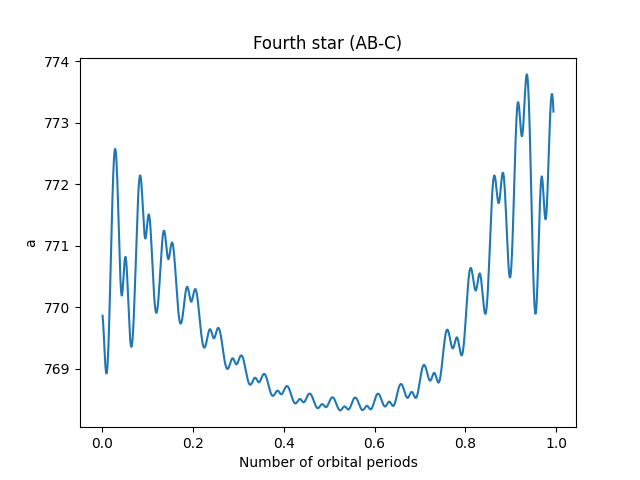

In [105]:
plt.close('all')

plt.figure(0)
plt.plot(times/P_AB_C, e4)
#plt.xlim([0, 300])
#plt.ylim([0.2, 0.25])

plt.xlabel('Number of orbital periods')
plt.ylabel('e')
plt.title('Fourth star (AB-C)')

plt.figure(1)
plt.plot(times/P_AB_C, a4)
#plt.xlim([0, 300])
#plt.ylim([0.675, 0.7])

plt.xlabel('Number of orbital periods')
plt.ylabel('a')
plt.title('Fourth star (AB-C)')

Now, let's look into chaos analysis by tweaking some orbital parameters, and see how it disturbs the evolution of the orbits

# 2. Deviate orbit #1: change semi-major axis of inner binary (Aa-Ab)

-99.8131945264477 -15.646146989153634 0.0
-101.04297255609883 -29.103015633328372 0.0
-99.12421702917942 53.468149561910124 0.0
458.7953743007634 -12.17200285928154 0.0
<rebound.Orbit instance, a=13.613000000000007 e=0.007350000000000211 inc=0.0 Omega=0.0 omega=4.621255477432823 f=1.7763568394002505e-15> 178.9494799536675
<rebound.Orbit instance, a=96.61999999999996 e=0.22366999999999973 inc=0.0 Omega=0.0 omega=1.5544407846124173 f=0.0> 2785.313443489876
<rebound.Orbit instance, a=769.9 e=0.274 inc=0.0 Omega=0.0 omega=6.256661176918607 f=4.440892098500626e-15> 56770.856159769166


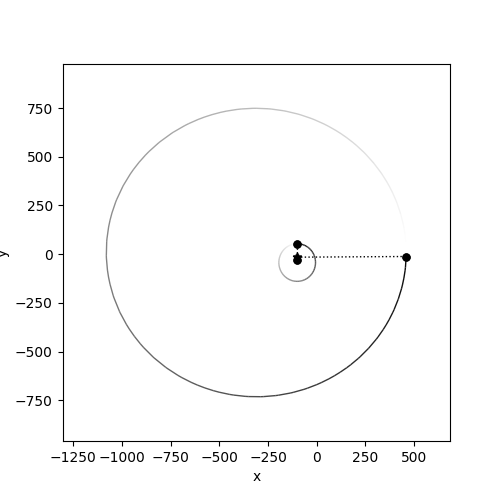

In [128]:
sim = rebound.Simulation()
sim.add(m=m_Aa, hash='star_Aa')
sim.add(m=m_Ab, a=a_Aa_Ab+0.037, e=e_Aa_Ab, omega=omega_Aa_Ab, hash='star_Ab')

sim.add(m=m_B, a=a_A_B, e=e_A_B, omega=omega_A_B, hash='star_B')
sim.add(m=m_C, a=a_AB_C, e=e_AB_C, omega=omega_AB_C, hash='star_C')


sim.move_to_com()

# plot the positions and instantaneous orbit
op = rebound.OrbitPlot(sim, periastron=True)

# output info about the particles and the orbit
for p in sim.particles:
    print(p.x, p.y, p.z)
for o in sim.orbits(): 
    print(o, o.P)

In [129]:
p_orb = sim.particles['star_C'].P

Norbits = 1
Noutputs = 2000

times = np.zeros(Noutputs)

xvec1 = [sim.particles['star_Aa'].x]
yvec1 = [sim.particles['star_Aa'].y]
vxvec1 = [sim.particles['star_Aa'].vx]
vyvec1 = [sim.particles['star_Aa'].vy]

xvec2 = [sim.particles['star_Ab'].x]
yvec2 = [sim.particles['star_Ab'].y]
a2 = np.zeros(Noutputs)
e2 = np.zeros(Noutputs)
vxvec2 = [sim.particles['star_Ab'].vx]
vyvec2 = [sim.particles['star_Ab'].vy]

xvec3 = [sim.particles['star_B'].x]
yvec3 = [sim.particles['star_B'].y]
vxvec3 = [sim.particles['star_B'].vx]
vyvec3 = [sim.particles['star_B'].vy]
a3 = np.zeros(Noutputs)
e3 = np.zeros(Noutputs)

xvec4 = [sim.particles['star_C'].x]
yvec4 = [sim.particles['star_C'].y]
vxvec4 = [sim.particles['star_C'].vx]
vyvec4 = [sim.particles['star_C'].vy]
a4 = np.zeros(Noutputs)
e4 = np.zeros(Noutputs)

op2, = plt.plot(xvec1, yvec1)

for i in range(Noutputs):

    op.sim.integrate(sim.t + (Norbits/Noutputs)*p_orb)

    times[i] = sim.t

    # store the trajectory + velocity of star Aa
    xvec1.append(sim.particles['star_Aa'].x)
    yvec1.append(sim.particles['star_Aa'].y)
    vxvec1.append(sim.particles['star_Aa'].vx)
    vyvec1.append(sim.particles['star_Aa'].vy)

    # store the trajectory + velocity + semi major axis + eccentricity of star Ab
    xvec2.append(sim.particles['star_Ab'].x)
    yvec2.append(sim.particles['star_Ab'].y)
    vxvec2.append(sim.particles['star_Ab'].vx)
    vyvec2.append(sim.particles['star_Ab'].vy)
    a2[i] = sim.particles['star_Ab'].a
    e2[i] = sim.particles['star_Ab'].e

    # store the trajectory + velocity + semi major axis + eccentricity of star B
    xvec3.append(sim.particles['star_B'].x)
    yvec3.append(sim.particles['star_B'].y)
    vxvec3.append(sim.particles['star_B'].vx)
    vyvec3.append(sim.particles['star_B'].vy)
    a3[i] = sim.particles['star_B'].a
    e3[i] = sim.particles['star_B'].e

    # store the trajectory + velocity + semi major axis + eccentricity of star C
    xvec4.append(sim.particles['star_C'].x)
    yvec4.append(sim.particles['star_C'].y)
    vxvec4.append(sim.particles['star_C'].vx)
    vyvec4.append(sim.particles['star_C'].vy)
    a4[i] = sim.particles['star_C'].a
    e4[i] = sim.particles['star_C'].e

    # update the plot to animate it
    op.update() #updateLimits=True) 
    op2.set_data((xvec1,yvec1)) 
    time.sleep(0.001)
    op.fig.canvas.draw()

Text(0.5, 1.0, 'Inner binary (Aa-Ab)')

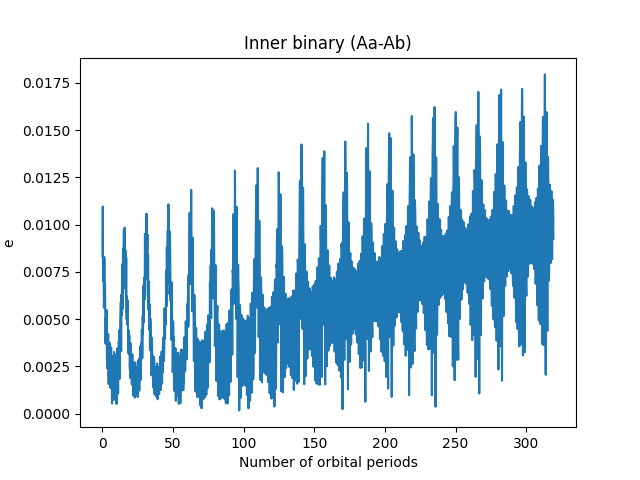

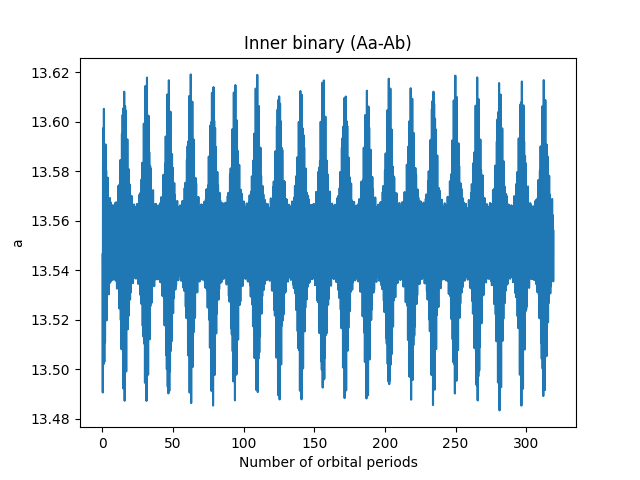

In [130]:
P_Aa_Ab = sim.particles['star_Ab'].P
P_A_B = sim.particles['star_B'].P
P_AB_C = sim.particles['star_C'].P

plt.close('all')

plt.figure(0)
plt.plot(times/P_Aa_Ab, e2)
#plt.xlim([0, 300])
#plt.ylim([0.2, 0.25])

plt.xlabel('Number of orbital periods')
plt.ylabel('e')
plt.title('Inner binary (Aa-Ab)')

plt.figure(1)
plt.plot(times/P_Aa_Ab, a2)
#plt.xlim([0, 300])
#plt.ylim([0.675, 0.7])

plt.xlabel('Number of orbital periods')
plt.ylabel('a')
plt.title('Inner binary (Aa-Ab)')

This is going to take an enormous amount of time to generate deviate orbits for each parameter for each star. To speed things up, let's functionalize this process and remove all animation. We calculate the orbits using:

1) the fiducial orbital parameters ('fiducial')
2) the fiducial orbital parameters w/ one parameter at its upper bound (fiducial + uncertainty; 'upper')
3) the fiducial orbital parameters w/ one parameter at its lower bound (fiducial - uncertainty; 'lower')

It seems rather complex to modulate a few parameters for a few stars individually into a single function (where, somehow, you could specificy in the intputs which parameters you want to tweak and for which stars). Instead, I resort to hard-coding the amount by which we want to change each parameter. It's not very clean but it's very clear for me, at least. 

In [237]:
def deviate_orbit(Noutputs, Norbits, print_params=False):

    plt.close('all')

    # first: simulate the fiducial

    sim = rebound.Simulation()
    sim.add(m=m_Aa, hash='star_Aa')
    sim.add(m=m_Ab, a=a_Aa_Ab, e=e_Aa_Ab, omega=omega_Aa_Ab, hash='star_Ab')
    
    sim.add(m=m_B, a=a_A_B, e=e_A_B, omega=omega_A_B, hash='star_B')
    sim.add(m=m_C, a=a_AB_C, e=e_AB_C, omega=omega_AB_C, hash='star_C')
    
    
    sim.move_to_com()
    
    ## plot the positions and instantaneous orbit
    op = rebound.OrbitPlot(sim, periastron=True)
    
    ## output info about the particles and the orbit
    if print_params:
        for p in sim.particles:
            print(p.x, p.y, p.z)
        for o in sim.orbits(): 
            print(o, o.P)


    ## integrate as a function of the number of orbits of the outer most star
    p_orb_ab_c = sim.particles['star_C'].P

    p_orb_aa_ab= sim.particles['star_Ab'].P
    p_orb_a_b = sim.particles['star_B'].P

    p_orbs = p_orb_aa_ab, p_orb_a_b, p_orb_ab_c
    
    times = np.zeros(Noutputs)
    
    xvec1 = [sim.particles['star_Aa'].x]
    yvec1 = [sim.particles['star_Aa'].y]
    vxvec1 = [sim.particles['star_Aa'].vx]
    vyvec1 = [sim.particles['star_Aa'].vy]
    
    xvec2 = [sim.particles['star_Ab'].x]
    yvec2 = [sim.particles['star_Ab'].y]
    a2 = np.zeros(Noutputs)
    e2 = np.zeros(Noutputs)
    vxvec2 = [sim.particles['star_Ab'].vx]
    vyvec2 = [sim.particles['star_Ab'].vy]
    
    xvec3 = [sim.particles['star_B'].x]
    yvec3 = [sim.particles['star_B'].y]
    vxvec3 = [sim.particles['star_B'].vx]
    vyvec3 = [sim.particles['star_B'].vy]
    a3 = np.zeros(Noutputs)
    e3 = np.zeros(Noutputs)
    
    xvec4 = [sim.particles['star_C'].x]
    yvec4 = [sim.particles['star_C'].y]
    vxvec4 = [sim.particles['star_C'].vx]
    vyvec4 = [sim.particles['star_C'].vy]
    a4 = np.zeros(Noutputs)
    e4 = np.zeros(Noutputs)
    
    print('--------------------------------------------------')
    print('Start integration of fiducial orbits...')
    
    for i in range(Noutputs):
    
        op.sim.integrate(sim.t + (Norbits/Noutputs)*p_orb_ab_c)
    
        times[i] = sim.t
    
        ## store the trajectory + velocity of star Aa
        xvec1.append(sim.particles['star_Aa'].x)
        yvec1.append(sim.particles['star_Aa'].y)
        vxvec1.append(sim.particles['star_Aa'].vx)
        vyvec1.append(sim.particles['star_Aa'].vy)
    
        ## store the trajectory + velocity + semi major axis + eccentricity of star Ab
        xvec2.append(sim.particles['star_Ab'].x)
        yvec2.append(sim.particles['star_Ab'].y)
        vxvec2.append(sim.particles['star_Ab'].vx)
        vyvec2.append(sim.particles['star_Ab'].vy)
        a2[i] = sim.particles['star_Ab'].a
        e2[i] = sim.particles['star_Ab'].e
    
        ## store the trajectory + velocity + semi major axis + eccentricity of star B
        xvec3.append(sim.particles['star_B'].x)
        yvec3.append(sim.particles['star_B'].y)
        vxvec3.append(sim.particles['star_B'].vx)
        vyvec3.append(sim.particles['star_B'].vy)
        a3[i] = sim.particles['star_B'].a
        e3[i] = sim.particles['star_B'].e
    
        ## store the trajectory + velocity + semi major axis + eccentricity of star C
        xvec4.append(sim.particles['star_C'].x)
        yvec4.append(sim.particles['star_C'].y)
        vxvec4.append(sim.particles['star_C'].vx)
        vyvec4.append(sim.particles['star_C'].vy)
        a4[i] = sim.particles['star_C'].a
        e4[i] = sim.particles['star_C'].e

    print('Finished integration of fiducial orbits!')
    fiducial = xvec1, yvec1, vxvec1, vyvec1, xvec2, yvec2, vxvec2, vyvec2, xvec3, yvec3, vxvec3, vyvec3, xvec4, yvec4, vxvec4, vyvec4, a2, e2, a3, e3, a4, e4
    
    # second: integrate the upper bound deviate

    sim = rebound.Simulation()
    sim.add(m=m_Aa, hash='star_Aa')
    sim.add(m=m_Ab, a=a_Aa_Ab+0.037, e=e_Aa_Ab, omega=omega_Aa_Ab, hash='star_Ab')
    
    sim.add(m=m_B, a=a_A_B, e=e_A_B, omega=omega_A_B, hash='star_B')
    sim.add(m=m_C, a=a_AB_C, e=e_AB_C, omega=omega_AB_C, hash='star_C')
    
    
    sim.move_to_com()
    
    ## plot the positions and instantaneous orbit
    op = rebound.OrbitPlot(sim, periastron=True)
    
    # output info about the particles and the orbit
    if print_params:
        for p in sim.particles:
            print(p.x, p.y, p.z)
        for o in sim.orbits(): 
            print(o, o.P)
    
    times = np.zeros(Noutputs)
    
    xvec1_up = [sim.particles['star_Aa'].x]
    yvec1_up = [sim.particles['star_Aa'].y]
    vxvec1_up = [sim.particles['star_Aa'].vx]
    vyvec1_up = [sim.particles['star_Aa'].vy]
    
    xvec2_up = [sim.particles['star_Ab'].x]
    yvec2_up = [sim.particles['star_Ab'].y]
    a2_up = np.zeros(Noutputs)
    e2_up = np.zeros(Noutputs)
    vxvec2_up = [sim.particles['star_Ab'].vx]
    vyvec2_up = [sim.particles['star_Ab'].vy]
    
    xvec3_up = [sim.particles['star_B'].x]
    yvec3_up = [sim.particles['star_B'].y]
    vxvec3_up = [sim.particles['star_B'].vx]
    vyvec3_up = [sim.particles['star_B'].vy]
    a3_up = np.zeros(Noutputs)
    e3_up = np.zeros(Noutputs)
    
    xvec4_up = [sim.particles['star_C'].x]
    yvec4_up = [sim.particles['star_C'].y]
    vxvec4_up = [sim.particles['star_C'].vx]
    vyvec4_up = [sim.particles['star_C'].vy]
    a4_up = np.zeros(Noutputs)
    e4_up = np.zeros(Noutputs)
    
    print('--------------------------------------------------')
    print('Start integration of upper bound deviate orbits...')
    
    for i in range(Noutputs):
    
        op.sim.integrate(sim.t + (Norbits/Noutputs)*p_orb_ab_c)
    
        times[i] = sim.t
    
        # store the trajectory + velocity of star Aa
        xvec1_up.append(sim.particles['star_Aa'].x)
        yvec1_up.append(sim.particles['star_Aa'].y)
        vxvec1_up.append(sim.particles['star_Aa'].vx)
        vyvec1_up.append(sim.particles['star_Aa'].vy)
    
        # store the trajectory + velocity + semi major axis + eccentricity of star Ab
        xvec2_up.append(sim.particles['star_Ab'].x)
        yvec2_up.append(sim.particles['star_Ab'].y)
        vxvec2_up.append(sim.particles['star_Ab'].vx)
        vyvec2_up.append(sim.particles['star_Ab'].vy)
        a2_up[i] = sim.particles['star_Ab'].a
        e2_up[i] = sim.particles['star_Ab'].e
    
        # store the trajectory + velocity + semi major axis + eccentricity of star B
        xvec3_up.append(sim.particles['star_B'].x)
        yvec3_up.append(sim.particles['star_B'].y)
        vxvec3_up.append(sim.particles['star_B'].vx)
        vyvec3_up.append(sim.particles['star_B'].vy)
        a3_up[i] = sim.particles['star_B'].a
        e3_up[i] = sim.particles['star_B'].e
    
        # store the trajectory + velocity + semi major axis + eccentricity of star C
        xvec4_up.append(sim.particles['star_C'].x)
        yvec4_up.append(sim.particles['star_C'].y)
        vxvec4_up.append(sim.particles['star_C'].vx)
        vyvec4_up.append(sim.particles['star_C'].vy)
        a4_up[i] = sim.particles['star_C'].a
        e4_up[i] = sim.particles['star_C'].e

    print('Finished integration of upper bound deviate orbits!')
    upper = xvec1_up, yvec1_up, vxvec1_up, vyvec1_up, xvec2_up, yvec2_up, vxvec2_up, vyvec2_up, xvec3_up, yvec3_up, vxvec3_up, vyvec3_up, xvec4_up, yvec4_up, vxvec4_up, vyvec4_up, a2_up, e2_up, a3_up, e3_up, a4_up, e4_up


    # third: integrate the lower bound deviate

    sim = rebound.Simulation()
    sim.add(m=m_Aa, hash='star_Aa')
    sim.add(m=m_Ab, a=a_Aa_Ab-0.046, e=e_Aa_Ab, omega=omega_Aa_Ab, hash='star_Ab')
    
    sim.add(m=m_B, a=a_A_B, e=e_A_B, omega=omega_A_B, hash='star_B')
    sim.add(m=m_C, a=a_AB_C, e=e_AB_C, omega=omega_AB_C, hash='star_C')
    
    
    sim.move_to_com()
    
    ## plot the positions and instantaneous orbit
    op = rebound.OrbitPlot(sim, periastron=True)
    
    # output info about the particles and the orbit
    if print_params:
        for p in sim.particles:
            print(p.x, p.y, p.z)
        for o in sim.orbits(): 
            print(o, o.P)
    
    times = np.zeros(Noutputs)
    
    xvec1_low = [sim.particles['star_Aa'].x]
    yvec1_low = [sim.particles['star_Aa'].y]
    vxvec1_low = [sim.particles['star_Aa'].vx]
    vyvec1_low = [sim.particles['star_Aa'].vy]
    
    xvec2_low = [sim.particles['star_Ab'].x]
    yvec2_low = [sim.particles['star_Ab'].y]
    a2_low = np.zeros(Noutputs)
    e2_low = np.zeros(Noutputs)
    vxvec2_low = [sim.particles['star_Ab'].vx]
    vyvec2_low = [sim.particles['star_Ab'].vy]
    
    xvec3_low = [sim.particles['star_B'].x]
    yvec3_low = [sim.particles['star_B'].y]
    vxvec3_low = [sim.particles['star_B'].vx]
    vyvec3_low = [sim.particles['star_B'].vy]
    a3_low = np.zeros(Noutputs)
    e3_low = np.zeros(Noutputs)
    
    xvec4_low = [sim.particles['star_C'].x]
    yvec4_low = [sim.particles['star_C'].y]
    vxvec4_low = [sim.particles['star_C'].vx]
    vyvec4_low = [sim.particles['star_C'].vy]
    a4_low = np.zeros(Noutputs)
    e4_low = np.zeros(Noutputs)
    
    print('--------------------------------------------------')
    print('Start integration of lower bound deviate orbits...')
    
    for i in range(Noutputs):
    
        op.sim.integrate(sim.t + (Norbits/Noutputs)*p_orb_ab_c)
    
        times[i] = sim.t
    
        # store the trajectory + velocity of star Aa
        xvec1_low.append(sim.particles['star_Aa'].x)
        yvec1_low.append(sim.particles['star_Aa'].y)
        vxvec1_low.append(sim.particles['star_Aa'].vx)
        vyvec1_low.append(sim.particles['star_Aa'].vy)
    
        # store the trajectory + velocity + semi major axis + eccentricity of star Ab
        xvec2_low.append(sim.particles['star_Ab'].x)
        yvec2_low.append(sim.particles['star_Ab'].y)
        vxvec2_low.append(sim.particles['star_Ab'].vx)
        vyvec2_low.append(sim.particles['star_Ab'].vy)
        a2_low[i] = sim.particles['star_Ab'].a
        e2_low[i] = sim.particles['star_Ab'].e
    
        # store the trajectory + velocity + semi major axis + eccentricity of star B
        xvec3_low.append(sim.particles['star_B'].x)
        yvec3_low.append(sim.particles['star_B'].y)
        vxvec3_low.append(sim.particles['star_B'].vx)
        vyvec3_low.append(sim.particles['star_B'].vy)
        a3_low[i] = sim.particles['star_B'].a
        e3_low[i] = sim.particles['star_B'].e
    
        # store the trajectory + velocity + semi major axis + eccentricity of star C
        xvec4_low.append(sim.particles['star_C'].x)
        yvec4_low.append(sim.particles['star_C'].y)
        vxvec4_low.append(sim.particles['star_C'].vx)
        vyvec4_low.append(sim.particles['star_C'].vy)
        a4_low[i] = sim.particles['star_C'].a
        e4_low[i] = sim.particles['star_C'].e

    print('Finished integration of lower bound deviate orbits!')
    lower = xvec1_low, yvec1_low, vxvec1_low, vyvec1_low, xvec2_low, yvec2_low, vxvec2_low, vyvec2_low, xvec3_low, yvec3_low, vxvec3_low, vyvec3_low, xvec4_low, yvec4_low, vxvec4_low, vyvec4_low, a2_low, e2_low, a3_low, e3_low, a4_low, e4_low

    return fiducial, upper, lower, p_orbs, times

In [243]:
fiducial_try, upper_try, lower_try, p_orbs_try, times_try = deviate_orbit(Noutputs=20000, Norbits=0.1)

--------------------------------------------------
Start integration of fiducial orbits...
Finished integration of fiducial orbits!
--------------------------------------------------
Start integration of upper bound deviate orbits...
Finished integration of upper bound deviate orbits!
--------------------------------------------------
Start integration of lower bound deviate orbits...
Finished integration of lower bound deviate orbits!


In [275]:
# simulation data for Star 1 (Aa)
fiducial_x1 = fiducial_try[0]
fiducial_y1 = fiducial_try[1]
fiducial_vx1 = fiducial_try[2]
fiducial_vy1 = fiducial_try[3]

upper_x1 = upper_try[0]
upper_y1 = upper_try[1]
upper_vx1 = upper_try[2]
upper_vy1 = upper_try[3]

lower_x1 = lower_try[0]
lower_y1 = lower_try[1]
lower_vx1 = lower_try[2]
lower_vy1 = lower_try[3]

# simulation data for Star 2 (Ab)
fiducial_x2 = fiducial_try[4]
fiducial_y2 = fiducial_try[5]
fiducial_vx2 = fiducial_try[6]
fiducial_vy2 = fiducial_try[7]

upper_x2 = upper_try[4]
upper_y2 = upper_try[5]
upper_vx2 = upper_try[6]
upper_vy2 = upper_try[7]

lower_x2 = lower_try[4]
lower_y2 = lower_try[5]
lower_vx2 = lower_try[6]
lower_vy2 = lower_try[7]

# simulation data for Star 3 (B)
fiducial_x3 = fiducial_try[8]
fiducial_y3 = fiducial_try[9]
fiducial_vx3 = fiducial_try[10]
fiducial_vy3 = fiducial_try[11]

upper_x3 = upper_try[8]
upper_y3 = upper_try[9]
upper_vx3 = upper_try[10]
upper_vy3 = upper_try[11]

lower_x3 = lower_try[8]
lower_y3 = lower_try[9]
lower_vx3 = lower_try[10]
lower_vy3 = lower_try[11]

# simulation data for Star 4 (C)
fiducial_x4 = fiducial_try[12]
fiducial_y4 = fiducial_try[13]
fiducial_vx4 = fiducial_try[14]
fiducial_vy4 = fiducial_try[15]

upper_x4 = upper_try[12]
upper_y4 = upper_try[13]
upper_vx4 = upper_try[14]
upper_vy4 = upper_try[15]

lower_x4 = lower_try[12]
lower_y4 = lower_try[13]
lower_vx4 = lower_try[14]
lower_vy4 = lower_try[15]

# semi-major axis, eccentricity of first orbit (Aa-Ab)
fiducial_a1 = fiducial_try[16]
upper_a1 = upper_try[16]
lower_a1 = lower_try[16]

fiducial_e1 = fiducial_try[17]
upper_e1 = upper_try[17]
lower_e1 = lower_try[17]

# semi-major axis, eccentricity of second orbit (A-B)
fiducial_a2 = fiducial_try[18]
upper_a2 = upper_try[18]
lower_a2 = lower_try[18]

fiducial_e2 = fiducial_try[19]
upper_e2 = upper_try[19]
lower_e2 = lower_try[19]

# semi-major axis, eccentricity of third orbit (AB-C)
fiducial_a3 = fiducial_try[20]
upper_a3 = upper_try[20]
lower_a3 = lower_try[20]

fiducial_e3 = fiducial_try[21]
upper_e3 = upper_try[21]
lower_e3 = lower_try[21]

# initial orbital periods
p_orbs_aa_ab = p_orbs_try[0]
p_orbs_a_b = p_orbs_try[1]
p_orbs_ab_c = p_orbs_try[2]

In [304]:
def visualize_data(fiducial_arr, upper_arr, lower_arr, times_arr, p_orbs_arr):

    # simulation data for Star 1 (Aa)
    fiducial_x1 = fiducial_arr[0]
    fiducial_y1 = fiducial_arr[1]
    fiducial_vx1 = fiducial_arr[2]
    fiducial_vy1 = fiducial_arr[3]
    
    upper_x1 = upper_arr[0]
    upper_y1 = upper_arr[1]
    upper_vx1 = upper_arr[2]
    upper_vy1 = upper_arr[3]
    
    lower_x1 = lower_arr[0]
    lower_y1 = lower_arr[1]
    lower_vx1 = lower_arr[2]
    lower_vy1 = lower_arr[3]
    
    # simulation data for Star 2 (Ab)
    fiducial_x2 = fiducial_arr[4]
    fiducial_y2 = fiducial_arr[5]
    fiducial_vx2 = fiducial_arr[6]
    fiducial_vy2 = fiducial_arr[7]
    
    upper_x2 = upper_arr[4]
    upper_y2 = upper_arr[5]
    upper_vx2 = upper_arr[6]
    upper_vy2 = upper_arr[7]
    
    lower_x2 = lower_arr[4]
    lower_y2 = lower_arr[5]
    lower_vx2 = lower_arr[6]
    lower_vy2 = lower_arr[7]
    
    # simulation data for Star 3 (B)
    fiducial_x3 = fiducial_arr[8]
    fiducial_y3 = fiducial_arr[9]
    fiducial_vx3 = fiducial_arr[10]
    fiducial_vy3 = fiducial_arr[11]
    
    upper_x3 = upper_arr[8]
    upper_y3 = upper_arr[9]
    upper_vx3 = upper_arr[10]
    upper_vy3 = upper_arr[11]
    
    lower_x3 = lower_arr[8]
    lower_y3 = lower_arr[9]
    lower_vx3 = lower_arr[10]
    lower_vy3 = lower_arr[11]
    
    # simulation data for Star 4 (C)
    fiducial_x4 = fiducial_arr[12]
    fiducial_y4 = fiducial_arr[13]
    fiducial_vx4 = fiducial_arr[14]
    fiducial_vy4 = fiducial_arr[15]
    
    upper_x4 = upper_arr[12]
    upper_y4 = upper_arr[13]
    upper_vx4 = upper_arr[14]
    upper_vy4 = upper_arr[15]
    
    lower_x4 = lower_arr[12]
    lower_y4 = lower_arr[13]
    lower_vx4 = lower_arr[14]
    lower_vy4 = lower_arr[15]
    
    # semi-major axis, eccentricity of first orbit (Aa-Ab)
    fiducial_a1 = fiducial_arr[16]
    upper_a1 = upper_arr[16]
    lower_a1 = lower_arr[16]
    
    fiducial_e1 = fiducial_arr[17]
    upper_e1 = upper_arr[17]
    lower_e1 = lower_arr[17]
    
    # semi-major axis, eccentricity of second orbit (A-B)
    fiducial_a2 = fiducial_arr[18]
    upper_a2 = upper_arr[18]
    lower_a2 = lower_arr[18]
    
    fiducial_e2 = fiducial_arr[19]
    upper_e2 = upper_arr[19]
    lower_e2 = lower_arr[19]
    
    # semi-major axis, eccentricity of third orbit (AB-C)
    fiducial_a3 = fiducial_arr[20]
    upper_a3 = upper_arr[20]
    lower_a3 = lower_arr[20]
    
    fiducial_e3 = fiducial_arr[21]
    upper_e3 = upper_arr[21]
    lower_e3 = lower_arr[21]
    
    # initial orbital periods
    p_orbs_aa_ab = p_orbs_arr[0]
    p_orbs_a_b = p_orbs_arr[1]
    p_orbs_ab_c = p_orbs_arr[2]

    plt.close('all')
    plt.figure(0)
    plt.plot(times_arr/p_orbs_aa_ab, fiducial_e1)
    plt.plot(times_arr/p_orbs_aa_ab, upper_e1)
    plt.plot(times_arr/p_orbs_aa_ab, lower_e1)
    
    
    plt.xlabel('Number of orbital periods')
    plt.ylabel('e')
    plt.title('Inner binary (Aa-Ab)')
    
    plt.show()
    
    plt.figure(1)
    plt.plot(times_arr/p_orbs_aa_ab, fiducial_a1)
    plt.plot(times_arr/p_orbs_aa_ab, upper_a1)
    plt.plot(times_arr/p_orbs_aa_ab, lower_a1)
    
    plt.xlabel('Number of orbital periods')
    plt.ylabel('a')
    plt.title('Inner binary (Aa-Ab)')
    
    plt.show()

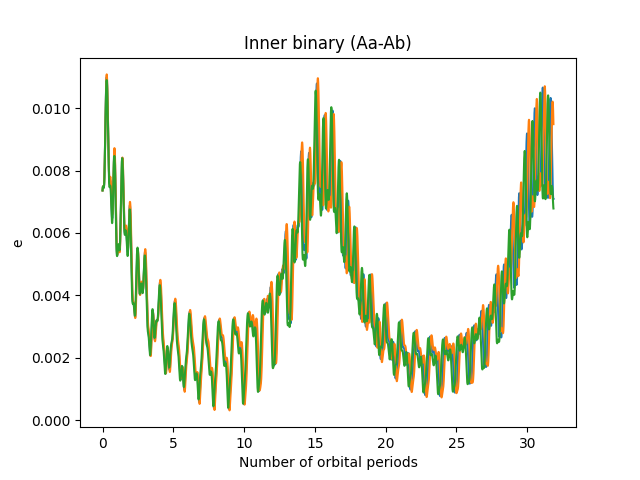

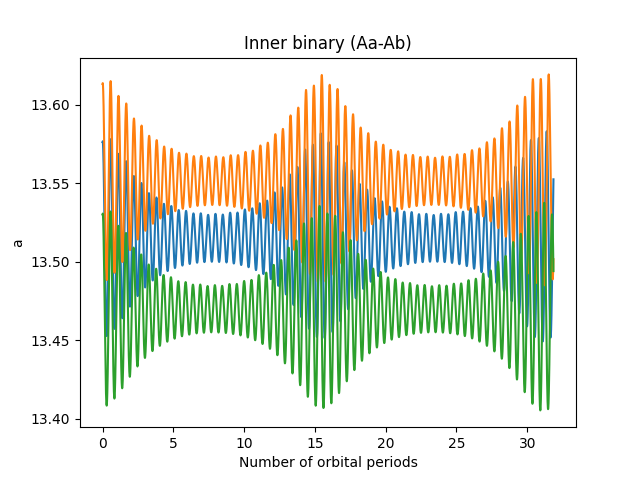

In [305]:
visualize_data(fiducial_arr=fiducial_try,
               upper_arr=upper_try,
               lower_arr=lower_try,
               times_arr=times_try,
               p_orbs_arr=p_orbs_try)

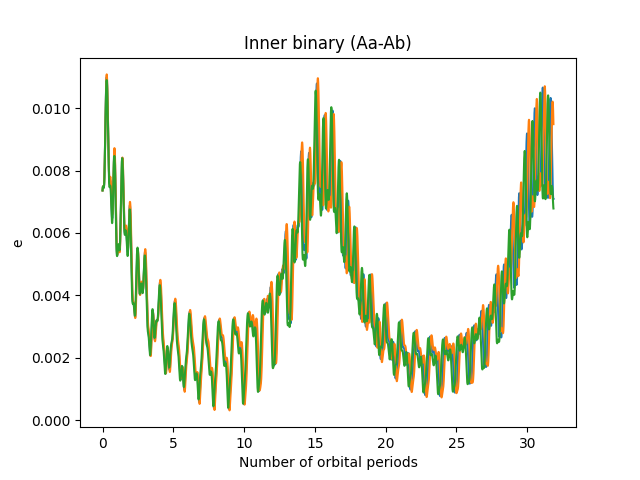

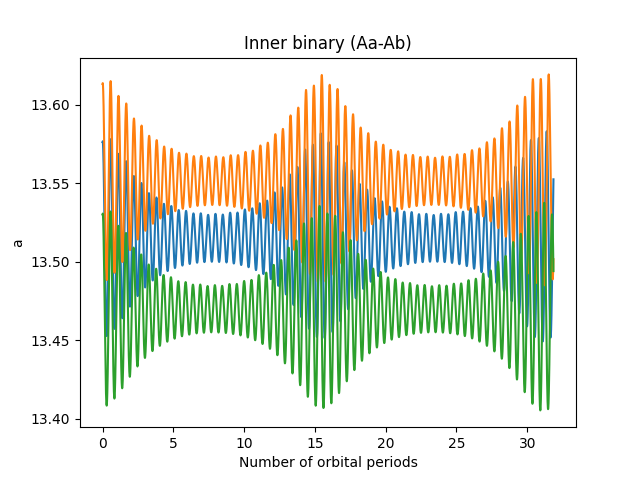

In [294]:
plt.close('all')

plt.figure(0)
plt.plot(times_try/p_orbs_aa_ab, fiducial_e1)
plt.plot(times_try/p_orbs_aa_ab, upper_e1)
plt.plot(times_try/p_orbs_aa_ab, lower_e1)


plt.xlabel('Number of orbital periods')
plt.ylabel('e')
plt.title('Inner binary (Aa-Ab)')

plt.show()

plt.figure(1)
plt.plot(times_try/p_orbs_aa_ab, fiducial_a1)
plt.plot(times_try/p_orbs_aa_ab, upper_a1)
plt.plot(times_try/p_orbs_aa_ab, lower_a1)

plt.xlabel('Number of orbital periods')
plt.ylabel('a')
plt.title('Inner binary (Aa-Ab)')

plt.show()

Text(0.5, 1.0, 'Inner binary (Aa-Ab)')

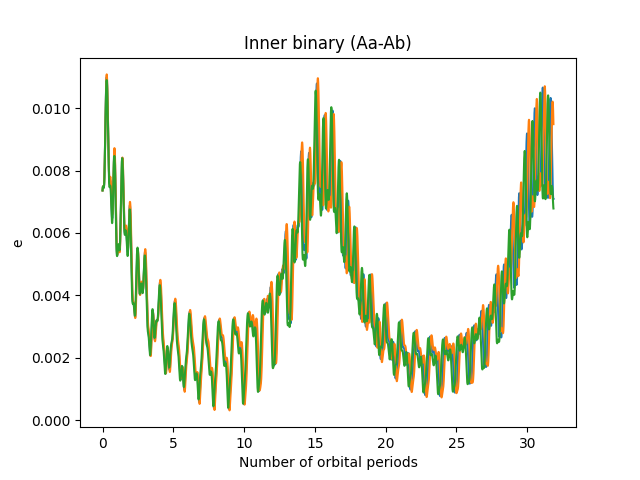

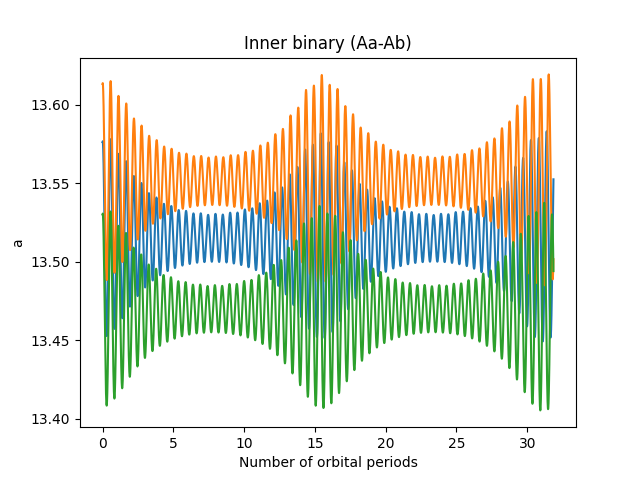

In [271]:
plt.close('all')

plt.figure(0)
plt.plot(times_try/p_orbs_aa_ab, fiducial_try[-5])
plt.plot(times_try/p_orbs_aa_ab, upper_try[-5])
plt.plot(times_try/p_orbs_aa_ab, lower_try[-5])


plt.xlabel('Number of orbital periods')
plt.ylabel('e')
plt.title('Inner binary (Aa-Ab)')

plt.figure(1)
plt.plot(times_try/p_orbs_aa_ab, fiducial_try[-6])
plt.plot(times_try/p_orbs_aa_ab, upper_try[-6])
plt.plot(times_try/p_orbs_aa_ab, lower_try[-6])

plt.xlabel('Number of orbital periods')
plt.ylabel('a')
plt.title('Inner binary (Aa-Ab)')

In [264]:
# my code from week 7:-)

def dfunc(x1, y1, x2, y2, vx1, vy1, vx2, vy2):
    
    '''
    calculates the phase-space distance between two trajectories (x1, y1, vx1, vy1) and (x2, y2, vx2, vy2)
    '''
    
    return np.sqrt((x1-x2)**2 + (y1-y2)**2 + (vx1-vx2)**2 + (vy1-vy2)**2)

def LCE(x1_0, x1, y1_0, y1, x2_0, x2, y2_0, y2, vx1_0, vx1, vy1_0, vy1, vx2_0, vx2, vy2_0, vy2, t0, t):

    '''
    calculates the LCE between two trajectories (x1, y1, vx1, vy1) and (x2, y2, vx2, vy2) between time 't0' and 't'
    '''

    d = dfunc(x1, y1, x2, y2, vx1, vy1, vx2, vy2)
    d0 = dfunc(x1_0, y1_0, x2_0, y2_0, vx1_0, vy1_0, vx2_0, vy2_0)
    
    gamma = np.log(d/d0)/(t-t0)
    
    return gamma

def make_LCEs(xvec1, yvec1, xvec2, yvec2, vxvec1, vyvec1, vxvec2, vyvec2, time_arr):

    '''
    calculates the LCE between two trajectories (x1, y1, vx1, vy1) and (x2, y2, vx2, vy2) 
    between an initial time 'time_arr[0]' and all subsequent times 'time_arr[i]'
    '''

    for i in range(len(time_arr)):
        if i==0:
            continue # skip i=0
    
        x1_0 = xvec1[0]
        y1_0 = yvec1[0]
        x2_0 = xvec2[0]
        y2_0 = yvec2[0]
        
        vx1_0 = vxvec1[0]
        vy1_0 = vyvec1[0]
        vx2_0 = vxvec2[0]
        vy2_0 = vyvec2[0]
    
        LCEs[i] = LCE(x1_0  = x1_0,
                      x1    = xvec1[i],
                      y1_0  = y1_0,
                      y1    = yvec1[i],
                      x2_0  = x2_0,
                      x2    = xvec2[i],
                      y2_0  = y2_0,
                      y2    = yvec2[i],
                      vx1_0 = vx1_0, 
                      vx1   = vxvec1[i],
                      vy1_0 = vy1_0,
                      vy1   = vyvec1[i],
                      vx2_0 = vx2_0,
                      vx2   = vxvec2[i],
                      vy2_0 = vy2_0,
                      vy2   = vyvec2[i],
                      t0    = time_arr[0], 
                      t     = time_arr[i]
                   )

    return LCEs

In [265]:
LCE_fiducial_upper_1 = make_LCEs(xvec1=fiducial_x1,
                                 yvec1=fiducial_y1,
                                 xvec2=upper_x1,
                                 yvec2=upper_y1,
                                 vxvec1=fiducial_vx1,
                                 vyvec1=fiducial_vy1,
                                 vxvec2=upper_vx1,
                                 vyvec2=upper_vy1,
                                 time_arr=times_try)

LCE_fiducial_lower_1 = make_LCEs(xvec1=fiducial_x1,
                                 yvec1=fiducial_y1,
                                 xvec2=lower_x1,
                                 yvec2=lower_y1,
                                 vxvec1=fiducial_vx1,
                                 vyvec1=fiducial_vy1,
                                 vxvec2=lower_vx1,
                                 vyvec2=lower_vy1,
                                 time_arr=times_try)

Text(0.5, 0, 'Number of orbital periods')

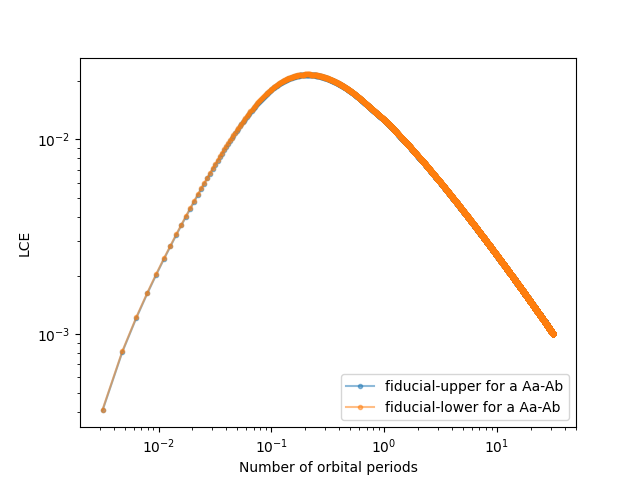

In [267]:
plt.close('all')
plt.plot(times_try[1:]/p_orbs_aa_ab, LCE_fiducial_upper_1[1:], '.-', label='fiducial-upper for a Aa-Ab', alpha=0.5)
plt.plot(times_try[1:]/p_orbs_aa_ab, LCE_fiducial_lower_1[1:], '.-', label='fiducial-lower for a Aa-Ab', alpha=0.5)

#plt.plot(times[1:]/p_orb, LCE_24[1:], label='chaotic orbits LCE')
plt.yscale('log')
plt.xscale('log')
plt.legend()

plt.ylabel('LCE')
plt.xlabel('Number of orbital periods')

Text(0.5, 0, 'Number of orbital periods')

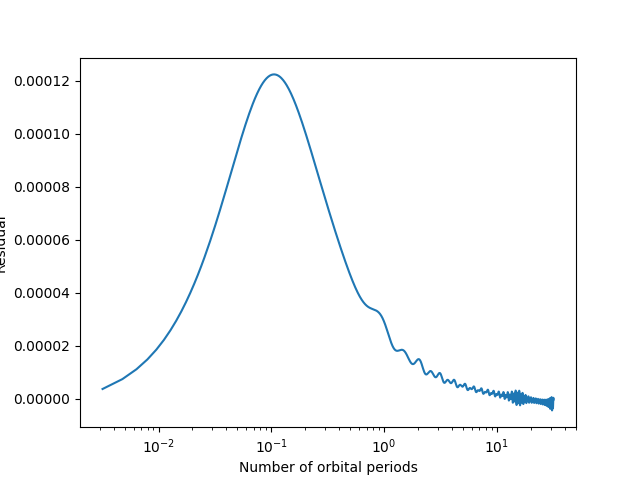

In [269]:
plt.close('all')

plt.plot(times_try[1:]/p_orbs_aa_ab, (LCE_fiducial_lower_1[1:] - LCE_fiducial_upper_1[1:]), alpha=1)

#plt.yscale('log')
plt.xscale('log')

plt.ylabel('Residual')
plt.xlabel('Number of orbital periods')


In [211]:
a_Aa_Ab

13.576

In [207]:
a_Aa_Ab+0.037

13.613000000000001

In [208]:
a_Aa_Ab-0.046

13.530000000000001

In [214]:
fiducial_try[-6][3]

np.float64(13.559224514491799)